In [24]:
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
insurance_data = pd.read_csv("raw_data/insurance.csv")

In [18]:
X=insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]
X = pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)
X["sex"]= X["sex"].map({"male":0,"female":1})
X["smoker"]= X["smoker"].map({"yes":1,"no":0})

X["age_smoker"] = X["age"]*X["smoker"]
X["bmi_smoker"] = X["bmi"]*X["smoker"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


<Axes: >

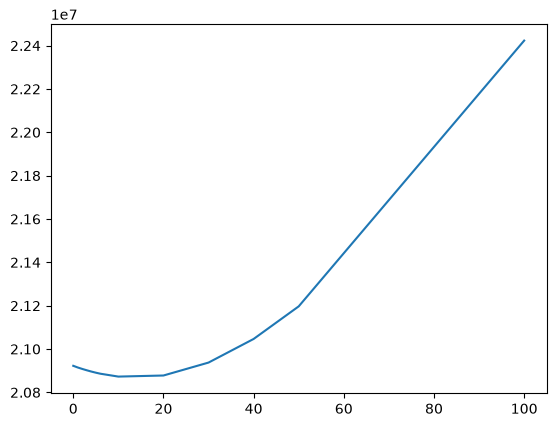

In [32]:
alphas = [0.001,0.1,1,2,3,4,5,6,10,20,30,40,50,100]
mses = []
for i in alphas:
    lasso_model = Lasso(alpha = i)
    lasso_model.fit(X_train,y_train)

    y_pred= lasso_model.predict(X_test)
    mses.append(mean_squared_error(y_test,y_pred))
sns.lineplot(x=alphas,y=mses,markers="*")

In [ ]:
#lassoCV
from sklearn.linear_model import LassoCV
a = [0.001,0.1,1,2,3,4,5,6,10,20,30,40,50,100]
lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter =100,
    random_state = 42  
)
lasso_cv_model.fit(X_train,y_train)
print("best alpha : ",lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)


best alpha :  0.001
mse =  20889718.149677318


c:\Users\Anonnyous\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.117204e+09, tolerance: 1.242e+07
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Anonnyous\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.918973e+08, tolerance: 1.242e+07
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Anonnyous\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number 

In [41]:
print("mse = ",mse)
r2 = r2_score(y_test,y_pred)
r2


mse =  20889718.149677318


0.8654435501730058